<a href="https://colab.research.google.com/github/jellyandcream494/dogsandcats/blob/main/dogs_vs_cats_layer1dropout_0.01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dog or Cat: Image Classification with CNN
In this example, you will classify whether an image contains either a dog or a cat. The **Dogs vs Cats** dataset was used for a Kaggle machine learning competition held in 2013, back when CNN was not mainstream. The dataset contains 25,000 photos for training (12,500 from each class); and 12,500 unlabeled photos for testing. Unsurprisingly, the dogs-vs-cats Kaggle competition in 2013 was won by entrants who used CNN, achieving up to 95% accuracy.

As a practical example, we will only use a small subset of the dataset containing 2,000 images for training, 1,000 for validation and 1,000 for testing.

In this tutorial, you will learn:
1. how to set up Google Colab.
 * how to access the Google Drive in the Google Colab.
 * how to enable GPU for traing your model
 * how to download dataset from Kaggle directly to Google Drive. (This step is optional—an alternative solution is provided in the comments.)
2. how to train a small ConvNet from scratch, without any regularization. It would set a baseline for what can be achieved.



## Setting-Up 1: Mount Google Drive to the notebook


You can easily load data from Google Drive by mounting it to the notebook. To do this, type the following code in your notebook. Run it, you will see a link, and need enter some code. To get the code, you need first click the link. In the link, after logining to your Google Account, you will see a code. Copy it, and paste it here.

Then you will see "Mounted at /content/drive" -- done!

Now you will see your Google Drive files in the left pane (file explorer). Right click on the file and select 'Copy path'. Your file's full path will be like `/content/gdrive/MyDrive/Colab Notebooks/dogs_vs_cats.ipynb`.

Your current directory will be `/content/`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setting-Up 2: One click to enable FREE GPU
After you mounted your Google Drive, let’s enable GPU in your Colab notebook. In Google Colab, it is very easy to do so.

From task bar, click: Runtime ⇨ Change runtime type

Choose 'GPU' in the Hardware accelerator.

## Setting-Up 3: Download the dataset directly to Google Drive
-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

**Facing Issues Downloading the Dataset? Here’s an alternative solution!**

*Based on previous students' experiences, it is common for students to encounter issues when downloading the original dataset from Kaggle and creating a smaller version. To save you time, I have shared my small Dogs vs. Cats dataset (containing 4,000 images in total) [here](https://drive.google.com/drive/folders/1Bh18k1bDzn2Qx5XJF5p25DkNxfkL4Yqu).*

*1. Click the link above. It must be in the "shared with me" in your Google Drive.*

*2. Right-click this folder, choose "Organize"=>"Add shortcut to Drive", then specify the path where you would like to put it.*

*3. Then you can access its path after you mount the drive.*

Now, you can skip all the preparation steps and proceed directly to  "Step 1: Build the CNN network".

-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+



Follow the steps below, you will be able to download Kaggele datasets to google drive via Kaggle API. To do it, you need

**Step 1** — Get the API key from your Kaggle account (Yes, **you need have a Kaggle account**.):

Visit www.kaggle.com ⇨ login ⇨ Your profile ⇨ Setting ⇨ API ⇨ Create New Token

The “kaggle.json” file will be automatically downloaded.

**Step 2** - Upload the kaggle.json file

The following code will ask you to upload the kaggle.json to Google Colab.

In [ ]:
# from google.colab import files
# files.upload() #upload kaggle.json you just downloaded KGAT_67103da4d6e076952a43ce4dec165810

The below will install the kaggle API, and create the necessary folder path.

In [ ]:
# !pip install -q kaggle
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !ls ~/.kaggle
# !chmod 600 /root/.kaggle/kaggle.json  # set permission

**Step 3** — Download the required dataset and unzip it

Simply download the required dataset with the syntax:

`!kaggle competitions download -c ‘name_of_competition’ -p “target_colab_dir”`

Then unzip the `train.zip` to the folder `data/dogs-vs-cat/`. We don't need unzip the `test1.zip` (you may even delete it to save space), as there is no label information for the images in `test1.zip`. Therefore, the small dataset we will create will all come from `train.zip`.

The unzipping may take some time. When finished, you will have a `train/` folder that contains 25,000 JPEG files of dogs and cats. In case that not all the files are extracted, it is better to **check if there are truely 25,000 files** in the `train/` folder. To get the dataset's full path, in the left panel (file explorer), right click on the folder and select 'Copy path'.

The photos are labeled by their filename, with the word “dog” or “cat“. The file naming convention is as follows:
- cat.0.jpg
- cat.51.jpg
- cat.1140.jpg
- dog.40.jpg
- dog.1425.jpg
- ...

In [ ]:
# # Let's say you would like to save the data in data/dogs-vs-cats, first create it
# !mkdir /content/drive/MyDrive/Colab\ Notebooks/data
# !mkdir /content/drive/MyDrive/Colab\ Notebooks/data/dogs-vs-cats
# # download the data using Kaggle API
# !kaggle competitions download -c dogs-vs-cats -p /content/drive/MyDrive/Colab\ Notebooks/data/dogs-vs-cats
# # Change the directory and unzip it
# import os
# os.chdir('/content/drive/MyDrive/Colab Notebooks/data/dogs-vs-cats')  #change dir
# #!unzip -o train.zip -d .  #unzip data, a folder train/ will be created
# !unzip -o dogs-vs-cats.zip -d .  #unzip data, a folder train/ will be created
# !unzip -o train.zip -d .
# # Check if there are 25,000 files in the train/ folder.
# folder = '/content/drive/MyDrive/Colab Notebooks/data/dogs-vs-cats/train/'
# num_files = len([f for f in os.listdir(folder)if os.path.isfile(os.path.join(folder, f))])
# print("num of files in train/:%d" % (num_files))
# # If all worked well, you may choose to remove the zip files to save some space
# !rm /content/drive/MyDrive/Colab\ Notebooks/data/dogs-vs-cats/*.zip

## Visualize a few photos
Display a few dog and cat images in the `train/` folder to have a first impression of the dataset. You must see that the photos are all different sizes, and also have almost all the challenges for visual recognition, such as intra-class variation, background clustter, deformation, viewpoint variation, scale variation, and so on.

In [ ]:
# import os
# import matplotlib.pyplot as plt
# from matplotlib.image import imread
# folder = '/content/drive/MyDrive/Colab Notebooks/data/dogs-vs-cats/train/'
# plt.figure(figsize=(10,10))
# for i in range(10):
#     plt.subplot(4,5,i+1)
#     filename = folder + 'cat.' + str(i) + '.jpg'
#     if not os.path.exists(filename):
#       print ('No such file:'+filename)
#     image = imread(filename)
#     plt.imshow(image)
# for i in range(10):
#     plt.subplot(4,5,i+11)
#     filename = folder + 'dog.' + str(i) + '.jpg'
#     image = imread(filename)
#     plt.imshow(image)
# plt.show()

## Create the small dataset
We will create a new dataset containing three subsets: a training set with 1000 samples of each class, a validation set with 500 samples of each class, and a test set with 500 samples of each class. This step could also take some time.

In [ ]:
# import os, shutil
# gdrive_dir = '/content/drive/MyDrive/Colab Notebooks'
# original_dataset_dir = gdrive_dir+'/data/dogs-vs-cats/train'


# base_dir = gdrive_dir+'/data/dogs-vs-cats-small'
# train_dir = os.path.join(base_dir,'train')
# val_dir   = os.path.join(base_dir,'val')
# test_dir  = os.path.join(base_dir,'test')

# if not os.path.exists(base_dir):
#   os.mkdir(base_dir)
#   print("create base_dir")
# if not os.path.exists(train_dir):
#   os.mkdir(train_dir)
# if not os.path.exists(val_dir):
#   os.mkdir(val_dir)
# if not os.path.exists(test_dir):
#   os.mkdir(test_dir)

# n_train_per_class = 1000
# n_val_per_class = 500
# n_test_per_class = 500
# train_cats_dir = os.path.join(train_dir,'cats')
# train_dogs_dir = os.path.join(train_dir,'dogs')
# val_cats_dir   = os.path.join(val_dir,'cats')
# val_dogs_dir   = os.path.join(val_dir,'dogs')
# test_cats_dir  = os.path.join(test_dir,'cats')
# test_dogs_dir  = os.path.join(test_dir,'dogs')

# # train/cats
# print("Copying data to dogs-vs-cats-small/train/cats/ ...")
# if not os.path.exists(train_cats_dir):
#     os.mkdir(train_cats_dir)
#     fnames = ['cat.{}.jpg'.format(i) for i in range(n_train_per_class)]
#     i = 0
#     for fname in fnames:
#         src = os.path.join(original_dataset_dir,fname)
#         dst = os.path.join(train_cats_dir,fname)
#         shutil.copyfile(src, dst)
#         i+=1
#     print("%d training images for cat." % (i))

# # train/dogs
# print("Copying data to dogs-vs-cats-small/train/dogs/ ...")
# if not os.path.exists(train_dogs_dir):
#     os.mkdir(train_dogs_dir)
#     fnames = ['dog.{}.jpg'.format(i) for i in range(n_train_per_class)]
#     i = 0
#     for fname in fnames:
#         src = os.path.join(original_dataset_dir,fname)
#         dst = os.path.join(train_dogs_dir,fname)
#         shutil.copyfile(src, dst)
#         i+=1
#     print("%d training images for dog." % (i))

# # val/cats
# print("Copying data to dogs-vs-cats-small/val/cats/ ...")
# if not os.path.exists(val_cats_dir):
#     os.mkdir(val_cats_dir)
#     fnames = ['cat.{}.jpg'.format(i) for i in range(n_train_per_class, n_train_per_class+n_val_per_class)]
#     i = 0
#     for fname in fnames:
#         src = os.path.join(original_dataset_dir,fname)
#         dst = os.path.join(val_cats_dir,fname)
#         shutil.copyfile(src, dst)
#         i+=1
#     print("%d validation images for cat." % (i))

# # val/dogs
# print("Copying data to dogs-vs-cats-small/val/dogs/ ...")
# if not os.path.exists(val_dogs_dir):
#     os.mkdir(val_dogs_dir)
#     fnames = ['dog.{}.jpg'.format(i) for i in range(n_train_per_class, n_train_per_class+n_val_per_class)]
#     i = 0
#     for fname in fnames:
#         src = os.path.join(original_dataset_dir,fname)
#         dst = os.path.join(val_dogs_dir,fname)
#         shutil.copyfile(src, dst)
#         i+=1
#     print("%d validation images for dog." % (i))

# # test/cats
# print("Copying data to dogs-vs-cats-small/test/cats/ ...")
# if not os.path.exists(test_cats_dir):
#     os.mkdir(test_cats_dir)
#     fnames = ['cat.{}.jpg'.format(i) for i in range(n_train_per_class+n_val_per_class,n_train_per_class+n_val_per_class+n_test_per_class)]
#     i = 0
#     for fname in fnames:
#         src = os.path.join(original_dataset_dir,fname)
#         dst = os.path.join(test_cats_dir,fname)
#         shutil.copyfile(src, dst)
#         i+=1
#     print("%d test images for cat." % (i))

# # test/dogs
# print("Copying data to dogs-vs-cats-small/test/dogs/ ...")
# if not os.path.exists(test_dogs_dir):
#     os.mkdir(test_dogs_dir)
#     fnames = ['dog.{}.jpg'.format(i) for i in range(n_train_per_class+n_val_per_class,n_train_per_class+n_val_per_class+n_test_per_class)]
#     i = 0
#     for fname in fnames:
#         src = os.path.join(original_dataset_dir,fname)
#         dst = os.path.join(test_dogs_dir,fname)
#         shutil.copyfile(src, dst)
#         i+=1
#     print("%d test images for dog." % (i))

# print("Done!")

## STEP 1: Build the CNN network
Since we only have 2000 images for training, we will use a small convnet with 4 convolutional layers. Here, because you start from inputs of size 150 x 150, you end up with feature maps of size 7 x 7 just before the `Flatten` layer.

Note that the depth of the feature maps progressively increases in the network (from 32 to 128), whereas the size of the feature maps decreases (from 148 x 148 to 7 x 7). This is a pattern you'll see in most CNNs.

Because this is a binary-classficatin problem, you'll end the network with a single neuron (a `Dense` layer of size 1) and a `sigmoid` activation function, which will encode the probability that the network is looking at one class or the other.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

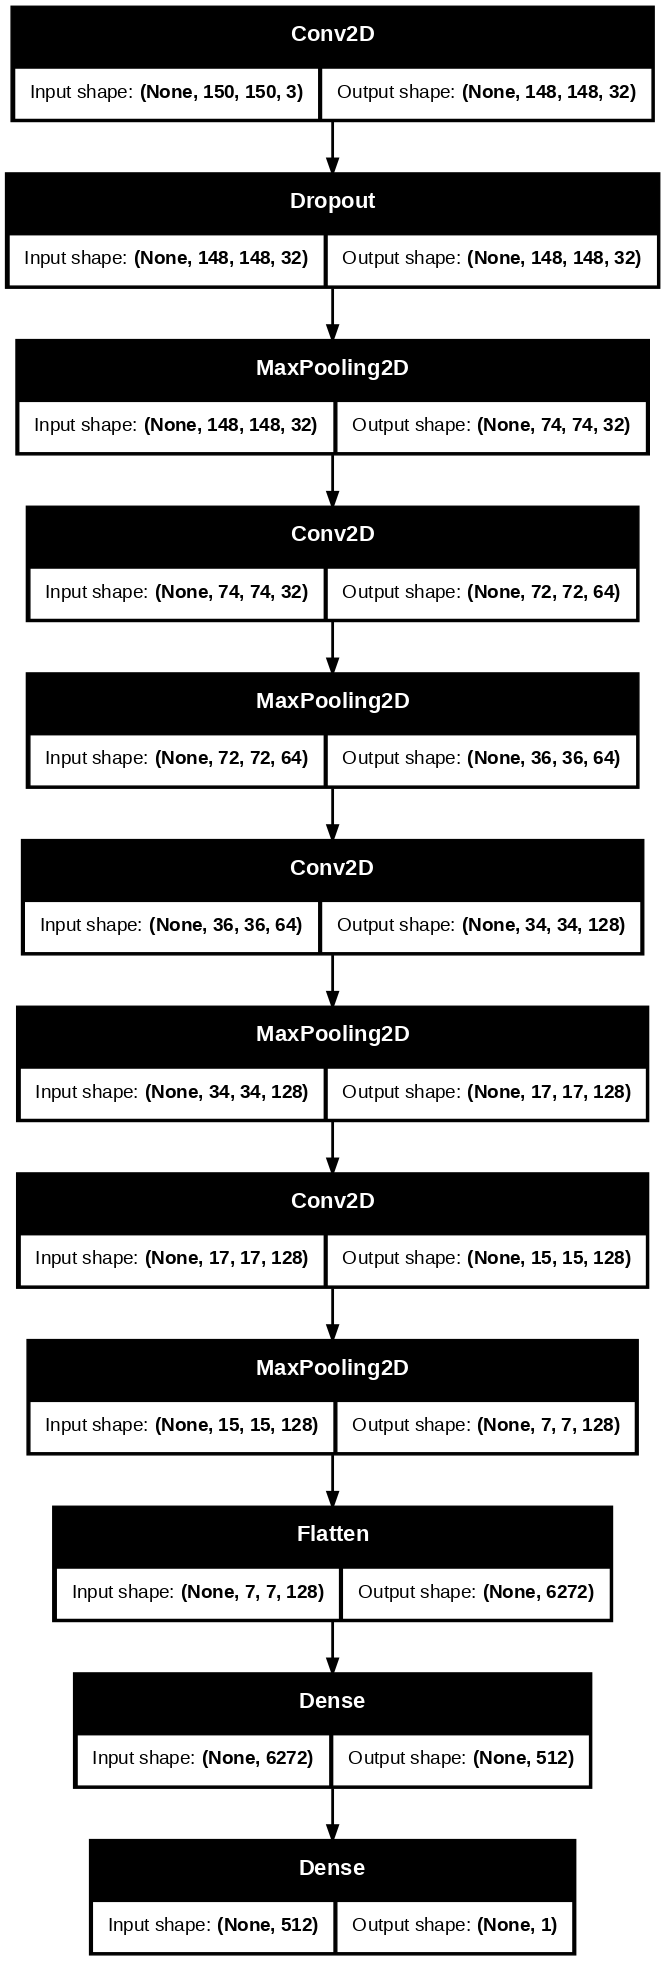

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.regularizers import l2


model = Sequential()

# baseline
# model.add(Input(shape=(150,150,3)))
# model.add(Conv2D(32, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(64, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Flatten())
# model.add(Dense(512, activation='relu'))

# TODO - change architecture/shape and add over/underfitting mitigations

λ = 0.0001


model.add(Input(shape=(150,150,3)))
model.add(Conv2D(32, (3, 3), kernel_regularizer=l2(λ), activation='relu'))
model.add(Dropout(0.01))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, dpi=100) # visualize the CNN artitecture

## STEP 2: Compile the model
The typical loss function for a binary classification problem is the binary cross-entropy loss function.

In [ ]:
model.compile(loss='binary_crossentropy',
            optimizer='adam',#adam (with default parameters) is always a good choice
            metrics=['accuracy'])

## STEP 3: Data preprocessing
Now we need do some pre-processing before feeding the data into the network.

Roughly, the preprocessing consists of following steps.
1. Read the image files, decode them to RGB grids of pixels
2. Rescale the pixel values (integers between 0 and 255) to the [0,1] interval, to enhance training stability of neural networks.
3. Apply data augmentation (not covered in this notebook but will be introduced later).

In earlier versions of TensorFlow, `ImageDataGenerator` was commonly used for loading and augmenting image data. However, in the latest versions of TensorFlow, it has been deprecated in favor of the `tf.data` API and Keras preprocessing `keras.layers`. Here’s why:

| Feature | ImageDataGenerator (Deprecated) | tf.data API (Recommended) |
|:--------:|:--------:|:--------:|
|  Performance   |  Slower (Python-based)   |  Faster (TensorFlow-optimized)   |
|  GPU Utilization   |  Limited   |  Efficient prefetching & parallel execution   |
|  Data Augmentation   |  Done in generator   |  Uses built-in Keras layers   |
| Future Support |Deprecated | Actively maintained|

Using `tf.keras.utils.image_dataset_from_directory()` ensures that images are loaded efficiently and processed using the `tf.data` pipeline, which is optimized for TensorFlow training.


In [ ]:
import tensorflow as tf

import os
gdrive_dir = '/content/drive/My Drive/MSc_AI/Unit9_ADL'
base_dir = gdrive_dir+'/data/dogs-vs-cats-small'
train_dir = os.path.join(base_dir,'train')
val_dir   = os.path.join(base_dir,'val')
test_dir  = os.path.join(base_dir,'test')

# Define batch size and image size
batch_size = 32
img_size = (150, 150)

# Load the training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size
)

# Load the validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size
)

# Normalize images (rescale pixel values to [0,1])
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Additional Performance Optimization (Optional)
# Benefit of using AUTOTUNE:
# 1. Loads the next batch while the current batch is being processed
# 2. Reduces data loading bottlenecks
# 3. Improves training speed
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


## STEP 4: Train the model
Now, let's train the CNN model using `model.fit()`. You only need to specify the training and validation datasets, along with the number of epochs.

It is always a good practice to save your model after training to preserve your results.

After training, be sure to plot the loss and accuracy for both the training and validation sets. Visualizing model performance over epochs is crucial for identifying potential overfitting and assessing overall learning progress.

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 412s 6s/step - accuracy: 0.5260 - loss: 0.6904 - val_accuracy: 0.5060 - val_loss: 0.7802
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.5330 - loss: 0.6988 - val_accuracy: 0.5950 - val_loss: 0.6852
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.5945 - loss: 0.6745 - val_accuracy: 0.6540 - val_loss: 0.6503
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.6595 - loss: 0.6291 - val_accuracy: 0.6510 - val_loss: 0.6215
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.7080 - loss: 0.5665 - val_accuracy: 0.6320 - val_loss: 0.6980
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.7440 - loss: 0.5391 - val_accuracy: 0.7010 - val_loss: 0.5794
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.7180 - loss: 0.5485 - val_accuracy: 0.7130 - val_loss: 0.5776
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.7735 - loss: 0.4747 - val_accuracy

Text(0.5, 0, 'epoch')

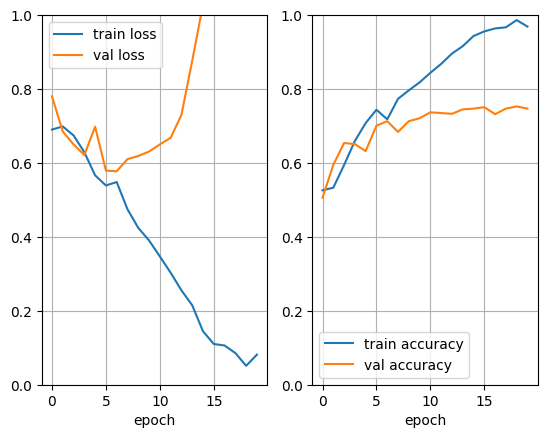

In [ ]:
# Train the model
epochs = 20
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs
)

model_folder = '/content/drive/My Drive/MSc_AI/Unit9_ADL/models'
import os
if not os.path.exists(model_folder):
    os.mkdir(model_folder)
model.save(model_folder+'/dogs_cats_small.keras_dropout_0.01')  # always save your model after training

# plot the learning curves
import matplotlib.pyplot as plt
fig = plt.figure()
fig.add_subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid(True)
plt.ylim([0,1.0])
plt.xlabel('epoch')

fig.add_subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0,1.0])
plt.xlabel('epoch')

The plots shown above exhibit clear signs of overfitting. Notably, the validation loss stopped dropping after around 5 epochs, while the training loss keeps decreasing almost to 0. After 5 epochs, the validation accuracy plateaus at around 71%.

We have only 2000 images for training, while there are 3.45 million parameters in even such a small CNN. Therefore, overfitting is our primary concern. In the upcoming lectures, we will delve into several strategies to mitigate the overfitting problem.

## STEP 5: Evaluate the model on the test set

We first omit this step, since the model we trained is still a baseline. We will investigate how to improve the model later. Then we can evaluate it on the test set.